## INTRODUCTION TO GEOSPATIAL DATA SCIENCES: TERM PROJECT
### Mapping the Carbon Footprint of German Exports to the EU: A Transport Mode Analysis

**Objective**:
To analyze and visualize the transport-related carbon emissions of Germany’s exports to the EU27, disaggregated by mode of transport (road, rail, sea, air), using monthly trade data and routing estimations.

**Key Research Questions:**
- What are the most emission-intensive export routes from Germany to EU partners?
-  Which transport modes dominate Germany’s intra-EU exports, and how do they vary by country?
- What is the spatial distribution of transport-related emissions from German trade within the EU?

**Note: Due to limited computational capacity, exact traffic routes could not be processed nor mapped**

In [ ]:
import pandas as pd
import numpy as np
import os
import sys
from IPython.display import HTML

## Data cleaning

In [2]:
cd = os.getcwd()  # Get the current working directory
germany_trade_df = pd.read_csv(os.path.join(cd, 'germany_2022_trade.csv')) # Read the CSV file from UN Comtrade
germany_trade_df

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
C,A,20220101,2022,52,2022,276,DEU,Germany,X,Export,...,True,0,False,NaN,1.189092e+09,1.189092e+09,4,False,True,NaN
C,A,20220101,2022,52,2022,276,DEU,Germany,X,Export,...,True,0,False,NaN,7.774350e+08,7.774350e+08,4,False,True,NaN
C,A,20220101,2022,52,2022,276,DEU,Germany,X,Export,...,True,0,False,NaN,2.213069e+08,2.213069e+08,4,False,True,NaN
C,A,20220101,2022,52,2022,276,DEU,Germany,X,Export,...,True,0,False,NaN,1.173147e+08,1.173147e+08,4,False,True,NaN
C,A,20220101,2022,52,2022,276,DEU,Germany,X,Export,...,True,0,False,NaN,8.905606e+07,8.905606e+07,4,False,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C,A,20220101,2022,52,2022,276,DEU,Germany,X,Export,...,True,0,False,NaN,1.925578e+10,1.925578e+10,4,False,True,NaN
C,A,20220101,2022,52,2022,276,DEU,Germany,X,Export,...,True,0,False,NaN,1.614418e+10,1.614418e+10,4,False,True,NaN
C,A,20220101,2022,52,2022,276,DEU,Germany,X,Export,...,True,0,False,NaN,6.428493e+09,6.428493e+09,4,False,True,NaN
C,A,20220101,2022,52,2022,276,DEU,Germany,X,Export,...,True,0,False,NaN,4.487355e+10,4.487355e+10,4,False,True,NaN


In [3]:
print(germany_trade_df.columns)

Index(['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period',
       'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc',
       'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code',
       'partner2ISO', 'partner2Desc', 'classificationCode',
       'classificationSearchCode', 'isOriginalClassification', 'cmdCode',
       'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc',
       'mosCode', 'motCode', 'motDesc', 'qtyUnitCode', 'qtyUnitAbbr', 'qty',
       'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty',
       'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt',
       'isGrossWgtEstimated', 'cifvalue', 'fobvalue', 'primaryValue',
       'legacyEstimationFlag', 'isReported', 'isAggregate'],
      dtype='object')


In [4]:
columns_to_keep = ['cmdCode', 'reporterCode', 'reporterISO', 'partnerCode', 'partnerISO',
                   'isOriginalClassification', 'motCode', 'refPeriodId', 'fobvalue', 'reporterDesc']
trade_df = germany_trade_df[columns_to_keep]
print(trade_df.head())

           cmdCode reporterCode reporterISO partnerCode partnerISO  \
C  All Commodities          DEU     Germany         AUT    Austria   
C  All Commodities          DEU     Germany         BEL    Belgium   
C  All Commodities          DEU     Germany         BGR   Bulgaria   
C  All Commodities          DEU     Germany         HRV    Croatia   
C  All Commodities          DEU     Germany         CYP     Cyprus   

  isOriginalClassification motCode  refPeriodId      fobvalue reporterDesc  
C                    TOTAL     Air         2022  1.189092e+09            X  
C                    TOTAL     Air         2022  7.774350e+08            X  
C                    TOTAL     Air         2022  2.213069e+08            X  
C                    TOTAL     Air         2022  1.173147e+08            X  
C                    TOTAL     Air         2022  8.905606e+07            X  


In [5]:
mod_names = {'cmdCode': 'comm_description', #commodity description
    'reporterCode': 'exporter_iso3', # exporter iso3 code
    'reporterISO': 'exporter_name', # exporter name
    'partnerCode': 'importer_iso3', # importer iso3 code
    'partnerISO': 'importer_name', # importer name
    'reporterDesc': 'export', # export
    'isOriginalClassification': 'comm_code', # commodity code
    'motCode': 'transport_mode', # transport mode
    'refPeriodId': 'year', 
    'fobvalue': 'trade_val_usd', # trade value in USD
}
trade_df = trade_df.rename(columns=mod_names).copy()
# reorder the columns
trade_df = trade_df[['year', 'exporter_iso3', 'exporter_name','export' ,'importer_iso3', 'importer_name',
                     'comm_code', 'comm_description', 'transport_mode', 'trade_val_usd']]

In [6]:
trade_df['year'] = pd.to_datetime(trade_df['year'], format='%Y') # Convert date to datetime
#save cleaned dataframe to csv
trade_df.to_csv(os.path.join(cd, 'germany_2022_trade_cleaned.csv'), index=False)

### validating $1/kg imputation based on monthly data: 

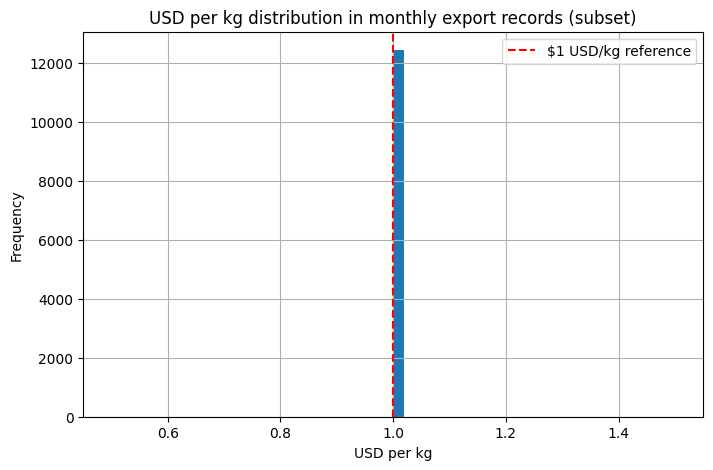

count    12430.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: usd_per_kg, dtype: float64

In [7]:
# Load a representative monthly-level subset (assumes you have it saved)
monthly_df = pd.read_csv("germany_2022_monthly_trade_cleaned.csv")  # e.g., a single commodity or a few months

# Keep only rows with valid weight and value
monthly_df = monthly_df[
    (monthly_df['gross_weight_kgs'].notna()) &
    (monthly_df['gross_weight_kgs'] > 0) &
    (monthly_df['trade_val_usd'].notna())
].copy()

# Calculate USD per kg
monthly_df['usd_per_kg'] = monthly_df['trade_val_usd'] / monthly_df['gross_weight_kgs']

# Plot histogram
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
monthly_df['usd_per_kg'].hist(bins=50)
plt.title("USD per kg distribution in monthly export records (subset)")
plt.xlabel("USD per kg")
plt.ylabel("Frequency")
plt.axvline(x=1, color='red', linestyle='--', label="$1 USD/kg reference")
plt.legend()
plt.grid(True)
plt.show()

# Show basic stats
monthly_df['usd_per_kg'].describe()


The above histogram shows the distribution of trade_val_usd / gross_weight_kgs for a representative subset of monthly export data.

The distribution is tightly centered around 1, confirming that the USD value of exports closely approximates the weight in kilograms for the majority of records.

**This approximation is now applied to the annual dataset**, where weight data is frequently missing or redacted, in order to estimate transport-related emissions consistently across records.

## Geospatial Data Preparation

### Defining Germany's Main Trading Hubs: 

In [8]:
germany_hubs = { #modes of transport, coordinates and share of trade
    "Sea": [
        {"city": "Hamburg", "lat": 53.5511, "lon": 9.9937, "share": 0.70},
        {"city": "Bremerhaven", "lat": 53.5396, "lon": 8.5809, "share": 0.30}
    ],
    "Road": [
        {"city": "Cologne", "lat": 50.9375, "lon": 6.9603, "share": 0.60},
        {"city": "Nuremberg", "lat": 49.4521, "lon": 11.0767, "share": 0.40}
    ],
    "Rail": [
        {"city": "Duisburg", "lat": 51.4344, "lon": 6.7623, "share": 0.65},
        {"city": "Mannheim", "lat": 49.4875, "lon": 8.4660, "share": 0.35}
    ],
    "Air": [
        {"city": "Frankfurt", "lat": 50.1109, "lon": 8.6821, "share": 0.70},
        {"city": "Leipzig", "lat": 51.3397, "lon": 12.3731, "share": 0.30}
    ]
}


In [9]:
trade_df.columns

Index(['year', 'exporter_iso3', 'exporter_name', 'export', 'importer_iso3',
       'importer_name', 'comm_code', 'comm_description', 'transport_mode',
       'trade_val_usd'],
      dtype='object')

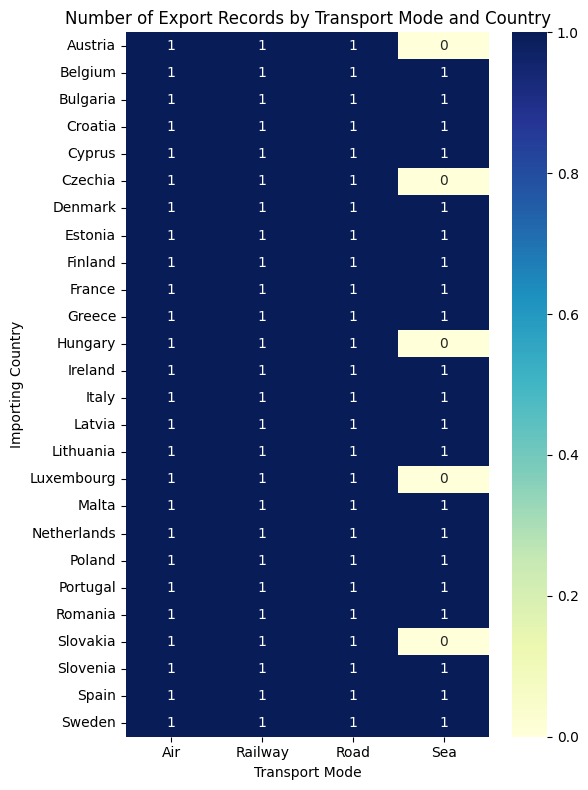

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Create a pivot table: rows as countries, columns as transport modes, values as counts
pivot_table = trade_df.pivot_table(
    index='importer_name',
    columns='transport_mode',
    values='trade_val_usd',
    aggfunc='count',
    fill_value=0
)

# Plot the heatmap
plt.figure(figsize=(6, 8))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Number of Export Records by Transport Mode and Country')
plt.xlabel('Transport Mode')
plt.ylabel('Importing Country')
plt.tight_layout()
plt.show()


### Main export destination for each EU trading parntner per transport mode

In [11]:
# define main destination hub per importing country per transport mode
eu27_trade_hubs = {
    "Austria": {
        "Road": [{"city": "Vienna", "lat": 48.2082, "lon": 16.3738, "share": 1.0}],
        "Rail": [{"city": "Vienna", "lat": 48.2082, "lon": 16.3738, "share": 1.0}],
        "Air": [{"city": "Vienna Intl.", "lat": 48.1103, "lon": 16.5697, "share": 1.0}],
        "Sea": []
    },
    "Belgium": {
        "Road": [{"city": "Brussels", "lat": 50.8503, "lon": 4.3517, "share": 1.0}],
        "Rail": [{"city": "Antwerp", "lat": 51.2194, "lon": 4.4025, "share": 1.0}],
        "Air": [{"city": "Brussels Airport", "lat": 50.9010, "lon": 4.4844, "share": 1.0}],
        "Sea": [{"city": "Antwerp Port", "lat": 51.2636, "lon": 4.3896, "share": 1.0}]
    },
    "Bulgaria": {
        "Road": [{"city": "Sofia", "lat": 42.6977, "lon": 23.3219, "share": 1.0}],
        "Rail": [{"city": "Sofia", "lat": 42.6977, "lon": 23.3219, "share": 1.0}],
        "Air": [{"city": "Sofia Airport", "lat": 42.6951, "lon": 23.4039, "share": 1.0}],
        "Sea": [{"city": "Varna", "lat": 43.2046, "lon": 27.9105, "share": 1.0}]
    },
    "Croatia": {
        "Road": [{"city": "Zagreb", "lat": 45.8150, "lon": 15.9819, "share": 1.0}],
        "Rail": [{"city": "Zagreb", "lat": 45.8150, "lon": 15.9819, "share": 1.0}],
        "Air": [{"city": "Zagreb Airport", "lat": 45.7429, "lon": 16.0688, "share": 1.0}],
        "Sea": [{"city": "Rijeka", "lat": 45.3271, "lon": 14.4422, "share": 1.0}]
    },
    "Cyprus": {
        "Road": [{"city": "Nicosia", "lat": 35.1856, "lon": 33.3823, "share": 1.0}],
        "Rail": [],
        "Air": [{"city": "Larnaca Intl.", "lat": 34.8721, "lon": 33.6232, "share": 1.0}],
        "Sea": [{"city": "Limassol", "lat": 34.7071, "lon": 33.0226, "share": 1.0}]
    },
    "Czechia": {
        "Road": [{"city": "Prague", "lat": 50.0755, "lon": 14.4378, "share": 1.0}],
        "Rail": [{"city": "Prague", "lat": 50.0755, "lon": 14.4378, "share": 1.0}],
        "Air": [{"city": "Prague Airport", "lat": 50.1008, "lon": 14.2632, "share": 1.0}],
        "Sea": []
    },
    "Denmark": {
        "Road": [{"city": "Copenhagen", "lat": 55.6761, "lon": 12.5683, "share": 1.0}],
        "Rail": [{"city": "Copenhagen", "lat": 55.6761, "lon": 12.5683, "share": 1.0}],
        "Air": [{"city": "Copenhagen Airport", "lat": 55.6181, "lon": 12.6560, "share": 1.0}],
        "Sea": [{"city": "Aarhus", "lat": 56.1629, "lon": 10.2039, "share": 1.0}]
    },
    "Estonia": {
        "Road": [{"city": "Tallinn", "lat": 59.4370, "lon": 24.7536, "share": 1.0}],
        "Rail": [{"city": "Tallinn", "lat": 59.4370, "lon": 24.7536, "share": 1.0}],
        "Air": [{"city": "Tallinn Airport", "lat": 59.4133, "lon": 24.8328, "share": 1.0}],
        "Sea": [{"city": "Muuga", "lat": 59.5000, "lon": 24.9667, "share": 1.0}]
    },
    "Finland": {
        "Road": [{"city": "Helsinki", "lat": 60.1695, "lon": 24.9354, "share": 1.0}],
        "Rail": [{"city": "Helsinki", "lat": 60.1695, "lon": 24.9354, "share": 1.0}],
        "Air": [{"city": "Helsinki Airport", "lat": 60.3172, "lon": 24.9633, "share": 1.0}],
        "Sea": [{"city": "Helsinki", "lat": 60.1695, "lon": 24.9354, "share": 1.0}]
    },
        "France": {
        "Road": [
            {"city": "Paris", "lat": 48.8566, "lon": 2.3522, "share": 0.6},
            {"city": "Lyon", "lat": 45.7640, "lon": 4.8357, "share": 0.4}
        ],
        "Rail": [
            {"city": "Paris", "lat": 48.8566, "lon": 2.3522, "share": 0.6},
            {"city": "Lyon", "lat": 45.7640, "lon": 4.8357, "share": 0.4}
        ],
        "Air": [
            {"city": "Paris Charles de Gaulle", "lat": 49.0097, "lon": 2.5479, "share": 0.7},
            {"city": "Lyon–Saint-Exupéry", "lat": 45.7256, "lon": 5.0811, "share": 0.3}
        ],
        "Sea": [
            {"city": "Le Havre", "lat": 49.4944, "lon": 0.1079, "share": 0.6},
            {"city": "Marseille", "lat": 43.2965, "lon": 5.3698, "share": 0.4}
        ]
    },
    "Greece": {
        "Road": [{"city": "Athens", "lat": 37.9838, "lon": 23.7275, "share": 1.0}],
        "Rail": [{"city": "Thessaloniki", "lat": 40.6401, "lon": 22.9444, "share": 1.0}],
        "Air": [{"city": "Athens Intl.", "lat": 37.9364, "lon": 23.9445, "share": 1.0}],
        "Sea": [{"city": "Piraeus", "lat": 37.9420, "lon": 23.6465, "share": 1.0}]
    },
    "Hungary": {
        "Road": [{"city": "Budapest", "lat": 47.4979, "lon": 19.0402, "share": 1.0}],
        "Rail": [{"city": "Budapest", "lat": 47.4979, "lon": 19.0402, "share": 1.0}],
        "Air": [{"city": "Budapest Airport", "lat": 47.4297, "lon": 19.2610, "share": 1.0}],
        "Sea": []
    },
    "Ireland": {
        "Road": [{"city": "Dublin", "lat": 53.3498, "lon": -6.2603, "share": 1.0}],
        "Rail": [{"city": "Dublin", "lat": 53.3498, "lon": -6.2603, "share": 1.0}],
        "Air": [{"city": "Dublin Airport", "lat": 53.4213, "lon": -6.2701, "share": 1.0}],
        "Sea": [{"city": "Dublin Port", "lat": 53.3460, "lon": -6.1950, "share": 1.0}]
    },
    "Italy": {
        "Road": [
            {"city": "Milan", "lat": 45.4642, "lon": 9.1900, "share": 0.6},
            {"city": "Rome", "lat": 41.9028, "lon": 12.4964, "share": 0.4}
        ],
        "Rail": [
            {"city": "Milan", "lat": 45.4642, "lon": 9.1900, "share": 0.6},
            {"city": "Rome", "lat": 41.9028, "lon": 12.4964, "share": 0.4}
        ],
        "Air": [
            {"city": "Milan Malpensa", "lat": 45.6301, "lon": 8.7281, "share": 0.6},
            {"city": "Rome Fiumicino", "lat": 41.8003, "lon": 12.2389, "share": 0.4}
        ],
        "Sea": [
            {"city": "Genoa", "lat": 44.4056, "lon": 8.9463, "share": 0.6},
            {"city": "Naples", "lat": 40.8518, "lon": 14.2681, "share": 0.4}
        ]
    },
    "Latvia": {
        "Road": [{"city": "Riga", "lat": 56.9496, "lon": 24.1052, "share": 1.0}],
        "Rail": [{"city": "Riga", "lat": 56.9496, "lon": 24.1052, "share": 1.0}],
        "Air": [{"city": "Riga Airport", "lat": 56.9236, "lon": 23.9711, "share": 1.0}],
        "Sea": [{"city": "Riga Port", "lat": 56.9707, "lon": 24.1073, "share": 1.0}]
    },
    "Lithuania": {
        "Road": [{"city": "Vilnius", "lat": 54.6872, "lon": 25.2797, "share": 1.0}],
        "Rail": [{"city": "Vilnius", "lat": 54.6872, "lon": 25.2797, "share": 1.0}],
        "Air": [{"city": "Vilnius Airport", "lat": 54.6341, "lon": 25.2856, "share": 1.0}],
        "Sea": [{"city": "Klaipėda", "lat": 55.7033, "lon": 21.1443, "share": 1.0}]
    },
    "Luxembourg": {
        "Road": [{"city": "Luxembourg City", "lat": 49.6117, "lon": 6.1319, "share": 1.0}],
        "Rail": [{"city": "Luxembourg Station", "lat": 49.5996, "lon": 6.1340, "share": 1.0}],
        "Air": [{"city": "Luxembourg Airport", "lat": 49.6233, "lon": 6.2044, "share": 1.0}],
        "Sea": []
    },
    "Malta": {
        "Road": [{"city": "Valletta", "lat": 35.8997, "lon": 14.5146, "share": 1.0}],
        "Rail": [],
        "Air": [{"city": "Malta International Airport", "lat": 35.8575, "lon": 14.4775, "share": 1.0}],
        "Sea": [{"city": "Marsaxlokk", "lat": 35.8417, "lon": 14.5431, "share": 1.0}]
    },
    "Netherlands": {
        "Road": [{"city": "Rotterdam", "lat": 51.9244, "lon": 4.4777, "share": 1.0}],
        "Rail": [{"city": "Rotterdam", "lat": 51.9244, "lon": 4.4777, "share": 1.0}],
        "Air": [{"city": "Amsterdam Airport Schiphol", "lat": 52.3105, "lon": 4.7683, "share": 1.0}],
        "Sea": [{"city": "Rotterdam Port", "lat": 51.9475, "lon": 4.1380, "share": 1.0}]
    },
    "Poland": {
        "Road": [{"city": "Warsaw", "lat": 52.2297, "lon": 21.0122, "share": 1.0}],
        "Rail": [{"city": "Warsaw", "lat": 52.2297, "lon": 21.0122, "share": 1.0}],
        "Air": [{"city": "Warsaw Chopin Airport", "lat": 52.1657, "lon": 20.9670, "share": 1.0}],
        "Sea": [{"city": "Gdańsk", "lat": 54.3520, "lon": 18.6466, "share": 1.0}]
    },
    "Portugal": {
        "Road": [{"city": "Lisbon", "lat": 38.7169, "lon": -9.1399, "share": 1.0}],
        "Rail": [{"city": "Lisbon", "lat": 38.7169, "lon": -9.1399, "share": 1.0}],
        "Air": [{"city": "Lisbon Airport", "lat": 38.7742, "lon": -9.1342, "share": 1.0}],
        "Sea": [{"city": "Lisbon Port", "lat": 38.7038, "lon": -9.1449, "share": 1.0}]
    },
    "Romania": {
        "Road": [{"city": "Bucharest", "lat": 44.4268, "lon": 26.1025, "share": 1.0}],
        "Rail": [{"city": "Bucharest", "lat": 44.4268, "lon": 26.1025, "share": 1.0}],
        "Air": [{"city": "Henri Coandă International Airport", "lat": 44.5711, "lon": 26.0850, "share": 1.0}],
        "Sea": [{"city": "Constanța", "lat": 44.1598, "lon": 28.6348, "share": 1.0}]
    },
    "Slovakia": {
        "Road": [{"city": "Bratislava", "lat": 48.1486, "lon": 17.1077, "share": 1.0}],
        "Rail": [{"city": "Bratislava", "lat": 48.1486, "lon": 17.1077, "share": 1.0}],
        "Air": [{"city": "Bratislava Airport", "lat": 48.1702, "lon": 17.2127, "share": 1.0}],
        "Sea": []
    },
    "Slovenia": {
        "Road": [{"city": "Ljubljana", "lat": 46.0569, "lon": 14.5058, "share": 1.0}],
        "Rail": [{"city": "Ljubljana", "lat": 46.0569, "lon": 14.5058, "share": 1.0}],
        "Air": [{"city": "Ljubljana Jože Pučnik Airport", "lat": 46.2230, "lon": 14.4576, "share": 1.0}],
        "Sea": [{"city": "Koper", "lat": 45.5469, "lon": 13.7294, "share": 1.0}]
    },
    "Spain": {
        "Road": [
            {"city": "Madrid", "lat": 40.4168, "lon": -3.7038, "share": 0.6},
            {"city": "Barcelona", "lat": 41.3851, "lon": 2.1734, "share": 0.4}
        ],
        "Rail": [
            {"city": "Madrid", "lat": 40.4168, "lon": -3.7038, "share": 0.6},
            {"city": "Barcelona", "lat": 41.3851, "lon": 2.1734, "share": 0.4}
        ],
     "Air": [
            {"city": "Madrid Barajas", "lat": 40.4983, "lon": -3.5676, "share": 0.6},
            {"city": "Barcelona El Prat", "lat": 41.2974, "lon": 2.0833, "share": 0.4}
        ],
        "Sea": [
            {"city": "Valencia", "lat": 39.4699, "lon": -0.3763, "share": 0.6},
            {"city": "Algeciras", "lat": 36.1408, "lon": -5.4562, "share": 0.4}
        ]
    },
    "Sweden": {
        "Road": [{"city": "Gothenburg", "lat": 57.7089, "lon": 11.9746, "share": 1.0}],
        "Rail": [{"city": "Gothenburg", "lat": 57.7089, "lon": 11.9746, "share": 1.0}],
        "Air": [{"city": "Stockholm Arlanda", "lat": 59.6519, "lon": 17.9186, "share": 1.0}],
        "Sea": [{"city": "Gothenburg Port", "lat": 57.7050, "lon": 11.9386, "share": 1.0}]
    }
}
   

In [12]:
import geopy.distance
import geopy
import folium
from geopy.distance import geodesic

In [13]:
# Define mapping from messy/raw to standardized transport modes
mode_fix = {
    'Railway': 'Rail',
    'Road': 'Road',
    'Sea': 'Sea',
    'Air': 'Air'
}

# Apply the mapping
trade_df['transport_mode'] = trade_df['transport_mode'].map(mode_fix)


In [14]:
# Check values in your dataframe
print(sorted(trade_df['importer_name'].unique()))

# Compare to your eu27_trade_hubs dictionary keys
print ('dic vals')
print(sorted(eu27_trade_hubs.keys()))


['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden']
dic vals
['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden']


Weighted Distance=i=1∑2​j=1∑2​shareij​×distanceij​

In [15]:
def compute_distances_to_EU_H1(row):
    country = row['importer_name']
    mode = row['transport_mode']

    origins = germany_hubs.get(mode, [])
    dests = eu27_trade_hubs.get(country, {}).get(mode, [])

    if len(origins) < 2 or len(dests) < 1:
        return pd.Series([None, None], index=['DE_H1_EU_H1', 'DE_H2_EU_H1'])

    o1, o2 = origins[0], origins[1]
    d1 = dests[0]

    d1_1 = geodesic((o1['lat'], o1['lon']), (d1['lat'], d1['lon'])).km
    d2_1 = geodesic((o2['lat'], o2['lon']), (d1['lat'], d1['lon'])).km

    return pd.Series([d1_1, d2_1], index=['DE_H1_EU_H1', 'DE_H2_EU_H1'])
def compute_distances_to_EU_H2(row):
    country = row['importer_name']
    mode = row['transport_mode']

    origins = germany_hubs.get(mode, [])
    dests = eu27_trade_hubs.get(country, {}).get(mode, [])

    if len(origins) < 2 or len(dests) < 2:
        return pd.Series([None, None], index=['DE_H1_EU_H2', 'DE_H2_EU_H2'])

    o1, o2 = origins[0], origins[1]
    d2 = dests[1]

    d1_2 = geodesic((o1['lat'], o1['lon']), (d2['lat'], d2['lon'])).km
    d2_2 = geodesic((o2['lat'], o2['lon']), (d2['lat'], d2['lon'])).km

    return pd.Series([d1_2, d2_2], index=['DE_H1_EU_H2', 'DE_H2_EU_H2'])
# Apply the function to compute distances
trade_df[['DE_H1_EU_H1', 'DE_H2_EU_H1']] = trade_df.apply(compute_distances_to_EU_H1, axis=1)
trade_df[['DE_H1_EU_H2', 'DE_H2_EU_H2']] = trade_df.apply(compute_distances_to_EU_H2, axis=1)



### Emissions Calculation

In [16]:
# Convert trade value to weight in tonnes (following 1kg = 1 usd assumption demonstrated above)
trade_df['weight_tonnes'] = trade_df['trade_val_usd'] / 1000


Based on the guidelines provided by the European Chemical Transport Association, the recommended average CO₂ emission factors are:
- Road transport: 62 g CO₂/tonne-km​
- Rail transport: 22 g CO₂/tonne-km​
- Short sea shipping: 16 g CO₂/tonne-km​
- Air freight: 602 g CO₂/tonne-km

In [17]:
# Map transport modes to emission factors (gCO₂/ton-km)
ef_map = {
    'Air': 602,
    'Sea': 16,
    'Road': 62,
    'Rail': 22
}

# Create the column
trade_df['emission_factor_ton'] = trade_df['transport_mode'].map(ef_map)


In [18]:
#compute shares of trade per hub
emissions_df = trade_df[['importer_name', 'transport_mode', 'emission_factor_ton', 'weight_tonnes',
    'DE_H1_EU_H1', 'DE_H1_EU_H2', 'DE_H2_EU_H1', 'DE_H2_EU_H2']].copy()
# Calculate the share of trade value for each importer per hub and transport mode
def compute_shares_general(row):
    country = row['importer_name']
    mode = row['transport_mode']

    origins = germany_hubs.get(mode, [])
    dests = eu27_trade_hubs.get(country, {}).get(mode, [])

    # Check how many valid entries exist
    if len(origins) < 2 or len(dests) == 0:
        return pd.Series([None]*4, index=[
            'S_DE_H1EU_H1', 'S_DE_H1EU_H2', 'S_DE_H2EU_H1', 'S_DE_H2EU_H2'
        ])

    o1_share, o2_share = origins[0]['share'], origins[1]['share']

    if len(dests) == 1:
        d1_share = dests[0]['share']
        return pd.Series([
            o1_share * d1_share,  # DE_H1 → EU_H1
            0.0,                  # DE_H1 → EU_H2
            o2_share * d1_share,  # DE_H2 → EU_H1
            0.0                   # DE_H2 → EU_H2
        ], index=['S_DE_H1EU_H1', 'S_DE_H1EU_H2', 'S_DE_H2EU_H1', 'S_DE_H2EU_H2'])

    # If there are 2 destinations
    d1_share, d2_share = dests[0]['share'], dests[1]['share']
    return pd.Series([
        o1_share * d1_share,
        o1_share * d2_share,
        o2_share * d1_share,
        o2_share * d2_share
    ], index=['S_DE_H1EU_H1', 'S_DE_H1EU_H2', 'S_DE_H2EU_H1', 'S_DE_H2EU_H2'])
# Apply the function to compute shares
emissions_df[['S_DE_H1EU_H1', 'S_DE_H1EU_H2', 'S_DE_H2EU_H1', 'S_DE_H2EU_H2']] = (
    emissions_df.apply(compute_shares_general, axis=1)
)



CO₂(kg)= ∑_ij(Weight (tonnes)×Distance_ij​ ×Share_ij×EF(gCO₂/ton-km)÷1000)

In [19]:
def compute_emission_routes(row):
    w = row['weight_tonnes']
    ef = row['emission_factor_ton']  # gCO₂ / ton-km

    emissions = {}

    # Define all 4 directional combinations and their corresponding output names
    route_definitions = [
        ('DE_H1_EU_H1', 'S_DE_H1EU_H1', 'CO2_DE_H1EU_H1'),
        ('DE_H1_EU_H2', 'S_DE_H1EU_H2', 'CO2_DE_H1EU_H2'),
        ('DE_H2_EU_H1', 'S_DE_H2EU_H1', 'CO2_DE_H2EU_H1'),
        ('DE_H2_EU_H2', 'S_DE_H2EU_H2', 'CO2_DE_H2EU_H2')
    ]

    for d_key, s_key, out_col in route_definitions:
        d = row.get(d_key)
        s = row.get(s_key)
        if pd.notna(d) and pd.notna(s):
            emissions[out_col] = round(w * d * ef * s / 1000, 4)
        else:
            emissions[out_col] = 0.0

    emissions['co2_kg'] = round(sum(emissions.values()), 4)
    return pd.Series(emissions)


In [20]:
emissions_df[
    ['CO2_DE_H1EU_H1', 'CO2_DE_H1EU_H2', 'CO2_DE_H2EU_H1', 'CO2_DE_H2EU_H2', 'co2_kg']
] = emissions_df.apply(compute_emission_routes, axis=1)


In [21]:
print(emissions_df.head(20))

  importer_name transport_mode  emission_factor_ton  weight_tonnes  \
C       Austria            Air                  602   1.189092e+06   
C       Belgium            Air                  602   7.774350e+05   
C      Bulgaria            Air                  602   2.213069e+05   
C       Croatia            Air                  602   1.173147e+05   
C        Cyprus            Air                  602   8.905606e+04   
C       Czechia            Air                  602   7.650727e+05   
C       Denmark            Air                  602   6.277292e+05   
C       Estonia            Air                  602   1.056530e+05   
C       Finland            Air                  602   4.864081e+05   
C        France            Air                  602   4.259943e+06   
C        Greece            Air                  602   3.660473e+05   
C       Hungary            Air                  602   1.365499e+06   
C       Ireland            Air                  602   7.968625e+05   
C         Italy     

In [22]:
final_df = emissions_df.melt(
    id_vars=['importer_name', 'transport_mode'],
    value_vars=[
        'CO2_DE_H1EU_H1', 'CO2_DE_H1EU_H2', 'CO2_DE_H2EU_H1', 'CO2_DE_H2EU_H2', 
    ],
    var_name='route',
    value_name='emissions_kg'
)
# save the final dataframe to csv
final_df.to_csv(os.path.join(cd, 'germany_eu27_trade_emissions.csv'), index=False)

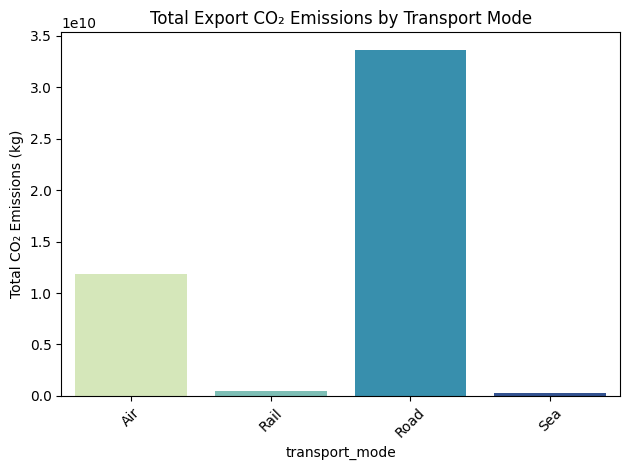

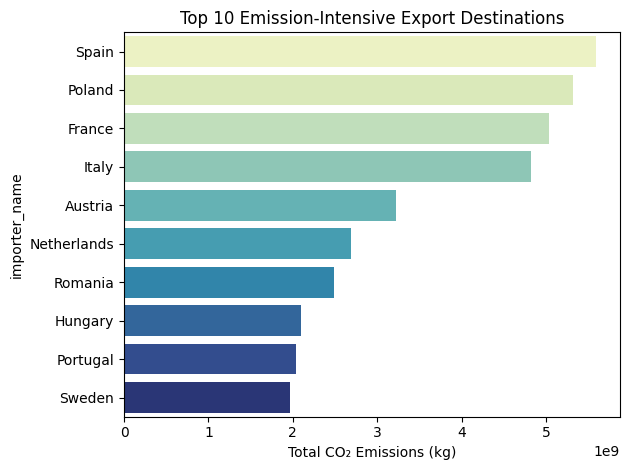

In [23]:
# Visualize the emissions
# Emissions by Transport Mode
grouped_mode = final_df.groupby("transport_mode", as_index=False).sum()

sns.barplot(
    data=grouped_mode,
    x="transport_mode",
    y="emissions_kg",
    hue="transport_mode",        
    palette="YlGnBu",
    dodge=False,
    legend=False
)
plt.ylabel("Total CO₂ Emissions (kg)")
plt.title("Total Export CO₂ Emissions by Transport Mode")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

top_countries = (
    final_df.groupby("importer_name", as_index=False)["emissions_kg"]
    .sum()
    .sort_values("emissions_kg", ascending=False)
    .head(10)
)
#  Emissions by Importer Country (Top 10)
sns.barplot(
    data=top_countries,
    x="emissions_kg",
    y="importer_name",
    hue="importer_name",         
    palette="YlGnBu",
    dodge=False,
    legend=False
)
plt.xlabel("Total CO₂ Emissions (kg)")
plt.title("Top 10 Emission-Intensive Export Destinations")
plt.tight_layout()
plt.show()


## maps

In [24]:
import matplotlib.colors as colors
import matplotlib

colormap = matplotlib.colormaps.get_cmap('coolwarm') 
norm = colors.Normalize(vmin=0, vmax=1e8)

def get_emission_color(emission_value):
    rgba = colormap(norm(emission_value))
    return colors.to_hex(rgba)

In [25]:
def get_emission_weight(emission_value):
    if emission_value == 0:
        return 0  # invisible
    elif emission_value < 1e6:       # < 1 million kg
        return 1
    elif emission_value < 1e7:       # < 10 million kg
        return 3
    elif emission_value < 5e7:       # < 50 million kg
        return 6
    else:
        return 10                    # heavy polluter

In [26]:
import folium
from branca.element import Template, MacroElement

def get_base_map():
    fmap = folium.Map(
        location=[54, 15],
        zoom_start=4.5,
        min_zoom=4,
        max_bounds=True
    )

    # Add bounds enforcement via JS
    bounds_js = """
    <script>
    function applyBounds(map) {
        var bounds = L.latLngBounds(
            L.latLng(34, -10),
            L.latLng(71, 35)
        );
        map.setMaxBounds(bounds);
        map.setZoom(Math.max(map.getZoom(), 4));
        map.options.minZoom = 4;
        map.options.maxZoom = 8;

        map.on('drag', function () {
            map.panInsideBounds(bounds, { animate: false });
        });

        map.on('zoomend', function () {
            if (map.getZoom() < 4) map.setZoom(4);
        });
    }

    setTimeout(function () {
        applyBounds(map);
    }, 1000);
    </script>
    """

    from folium import Element
    fmap.get_root().html.add_child(Element(bounds_js))

    return fmap

In [27]:
# Create and save base map
m = get_base_map()
m.save("results/zoom_limited_map.html")


In [28]:
# description emissions_kg
final_df['emissions_kg'].describe()

count    3.960000e+02
mean     1.168239e+08
std      3.002463e+08
min      0.000000e+00
25%      0.000000e+00
50%      9.951394e+05
75%      4.714417e+07
max      3.019318e+09
Name: emissions_kg, dtype: float64

In [29]:
def create_single_hub_map(df, origin_info, mode, dest_hubs_dict, save_path=None):
    df_mode = df[df["transport_mode"] == mode].copy()
    fmap = get_base_map()

    origin_coords = (origin_info["lat"], origin_info["lon"])
    origin_city = origin_info["city"]
    origin_share = origin_info["share"]

    for _, row in df_mode.iterrows():
        importer = row["importer_name"]
        total_emissions = row["emissions_kg"]

        destinations = dest_hubs_dict.get(importer, {}).get(mode, [])
        if not destinations:
            continue

        for destination in destinations:
            dest_coords = (destination["lat"], destination["lon"])
            share = origin_share * destination["share"]
            emission_share = total_emissions * share

            folium.PolyLine(
                locations=[origin_coords, dest_coords],
                color=get_emission_color(emission_share),
                weight=get_emission_weight(emission_share),
                opacity=0.6,
                tooltip=(
                    f"{origin_city} → {destination['city']}<br>"
                    f"{importer}, {mode}<br>"
                    f"CO₂: {emission_share:,.0f} kg"
                )
            ).add_to(fmap)

    if save_path:
        fmap.save(save_path)
        print(f"Map saved to: {save_path}")

    return fmap

In [30]:
# Choose a mode and hub to display
mode = "Road"  # Can be "Road", "Rail", "Sea", or "Air"
hub = germany_hubs[mode][0]  # First hub for this mode

# Create and display the map
single_map = create_single_hub_map(
    df=final_df,
    origin_info=hub,
    mode=mode,
    dest_hubs_dict=eu27_trade_hubs
)

# Display in notebook
single_map

In [31]:
from IPython.display import display, HTML
import ipywidgets as widgets

# Create tabs for each transport mode
tabs = widgets.Tab()

# Create output widgets for each mode
outputs = []
for mode in germany_hubs.keys():
    out = widgets.Output()
    with out:
        display(HTML(f"<h2>{mode} Transport</h2>"))
        for hub in germany_hubs[mode]:
            display(HTML(f"<h3>From {hub['city']}</h3>"))
            m = create_single_hub_map(
                df=final_df,
                origin_info=hub,
                mode=mode,
                dest_hubs_dict=eu27_trade_hubs
            )
            display(m)
    outputs.append(out)

# Assign the outputs to tabs.children first
tabs.children = outputs

# Set tab titles
titles = [f"{mode} Transport" for mode in germany_hubs.keys()]
for i, title in enumerate(titles):
    tabs.set_title(i, title)

# Display the tabs
display(tabs)